# ⚖️ Actividad 04: Normalización y Escalado Algorítmico
---
**Módulo 2: Feature Engineering para LSTM**

Las redes LSTM usan funciones de activación `tanh` (salida entre −1 y 1) y `sigmoid` (entre 0 y 1). Si la red recibe variables con rangos muy distintos —como toneladas de producción vs. temperaturas en °C— los gradientes se distorsionan y el entrenamiento se vuelve inestable. El escalado garantiza que **todas las variables contribuyan en igualdad de condiciones** al aprendizaje del modelo.

## 🎯 Objetivos
1. **Identificar** variables numéricas continuas a escalar (excluyendo fechas, IDs y columnas ya acotadas cíclicamente entre −1 y 1).
2. **Ajustar `StandardScaler`** únicamente sobre el **conjunto de entrenamiento** (primeros 80% cronológicos) para evitar *data leakage*.
3. **Transformar** el dataset completo con ese mismo scaler.
4. **Serializar los scalers** en `notebooks/fase2/scalers/` con `joblib` para reutilizarlos en la fase de inferencia futura.
5. **Exportar** el dataset final, listo para ser consumido por la LSTM.

> **¿Por qué StandardScaler y no MinMaxScaler?** Los datos de producción agrícola presentan alta asimetría (skew > 3) y outliers significativos (>7%), lo que distorsiona el rango [0,1] del MinMaxScaler cuando el conjunto de prueba supera los máximos de entrenamiento. El StandardScaler (media=0, σ=1) es estadísticamente más robusto frente a estas distribuciones según [52].

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler

# Configuración estética
sns.set_theme(style='whitegrid', palette='viridis')
%matplotlib inline

# ── Rutas ──────────────────────────────────────────────────────────────────────
INPUT_FILE   = '../../data/processed/master_dataset_fase2_lags.csv'
OUTPUT_FILE  = '../../data/processed/master_dataset_fase2_final.csv'
SCALERS_DIR  = 'scalers/'

os.makedirs(SCALERS_DIR, exist_ok=True)
print(f"Cargando dataset desde: {INPUT_FILE}")
print(f"Scalers se guardarán en: {os.path.abspath(SCALERS_DIR)}")


Cargando dataset desde: ../../data/processed/master_dataset_fase2_lags.csv
Scalers se guardarán en: C:\Users\alexc\OneDrive\Documentos\DATAPROCESADAINVESTIGACION\Machine-Learning-Multimodal--Agro-NLP-Clima-\notebooks\fase2\scalers


## 1. Carga del Dataset con Rezagos

In [2]:
df = pd.read_csv(INPUT_FILE)
df['fecha_evento'] = pd.to_datetime(df['fecha_evento'])

print(f"Dataset cargado: {df.shape[0]:,} filas, {df.shape[1]} columnas")
print(f"Rango temporal: {df['fecha_evento'].min().date()} → {df['fecha_evento'].max().date()}")
df.head(2)


Dataset cargado: 4,620 filas, 56 columnas
Rango temporal: 2022-01-01 → 2025-08-01


,fecha_evento,departamento,provincia,produccion_t,cosecha_ha,precio_chacra_kg,num_emergencias,total_afectados,ALLSKY_SFC_SW_DWN,PRECTOTCORR,...,WS2M_lag6,WS2M_lag12,ALLSKY_SFC_SW_DWN_lag1,ALLSKY_SFC_SW_DWN_lag3,ALLSKY_SFC_SW_DWN_lag6,ALLSKY_SFC_SW_DWN_lag12,nlp_sentiment_lag1,nlp_sentiment_lag3,nlp_sentiment_lag6,nlp_sentiment_lag12
0,2022-01-01,APURIMAC,ABANCAY,24.0,0.0,1.25,22.0,132.0,17.88,138.88,...,1.32,1.28,18.56,20.44,19.05,17.71,0.548314,0.065579,0.042592,0.0
1,2022-02-01,APURIMAC,ABANCAY,5.0,0.0,1.00,34.0,197.0,16.75,381.64,...,1.53,1.18,17.88,18.00,19.50,18.20,1.244420,0.247121,1.832662,0.0


## 2. Selección de Columnas a Escalar

**Se EXCLUYEN del escalado:**
- `fecha_evento` y columnas de texto/ID (son categorías, no numéricas continuas)
- `month_sin`, `month_cos`, `trimestre_sin`, `trimestre_cos` (ya están acotadas entre −1 y 1, re-escalar distorsionaría su geometría circular)

**Se INCLUYEN todas las demás numéricas:** variables objetivo, rezagos, variables NASA y NLP.

In [3]:
# Columnas a excluir del escalado
EXCLUDE_COLS = {
    'fecha_evento',
    # Cíclicas: ya están en [-1, 1]
    'month_sin', 'month_cos',
    'trimestre_sin', 'trimestre_cos',
    # IDs / texto
    'provincia', 'departamento', 'cultivo', 'region',
    'mes_num', 'trimestre_num',
}

# Detectar columnas numéricas continuas elegibles
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cols_to_scale = [c for c in numeric_cols if c not in EXCLUDE_COLS]

print(f"Total columnas numéricas : {len(numeric_cols)}")
print(f"Columnas excluidas       : {len([c for c in numeric_cols if c in EXCLUDE_COLS])}")
print(f"Columnas a escalar       : {len(cols_to_scale)}")
print(f"\nEjemplos de columnas a escalar: {cols_to_scale[:10]} ...")


Total columnas numéricas : 53
Columnas excluidas       : 2
Columnas a escalar       : 51

Ejemplos de columnas a escalar: ['produccion_t', 'cosecha_ha', 'precio_chacra_kg', 'num_emergencias', 'total_afectados', 'ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'QV2M', 'RH2M', 'T2M'] ...


## 3. División Temporal Train / Test (80/20)

Para evitar **Data Leakage**, el `MinMaxScaler` se ajusta (`fit`) **sólo** con los datos de entrenamiento (los primeros 80% cronológicos). Luego se aplica la transformación (`transform`) al dataset completo.

> ⚠️ En series de tiempo **NO** se hace un split aleatorio. Siempre se corta por fecha para respetar el orden causal: el pasado entrena, el futuro valida.

In [4]:
# Ordenamos por fecha globalmente (ya viene ordenado, pero por seguridad)
df = df.sort_values('fecha_evento').reset_index(drop=True)

# Punto de corte: 80% cronológico
cutoff_idx  = int(len(df) * 0.80)
cutoff_date = df.loc[cutoff_idx, 'fecha_evento']

df_train = df.iloc[:cutoff_idx]
df_test  = df.iloc[cutoff_idx:]

print(f"Total muestras : {len(df):,}")
print(f"Train (80%)    : {len(df_train):,} → hasta {df_train['fecha_evento'].max().date()}")
print(f"Test  (20%)    : {len(df_test):,}  → desde {df_test['fecha_evento'].min().date()}")
print(f"\nFecha de corte: {cutoff_date.date()}")


Total muestras : 4,620
Train (80%)    : 3,696 → hasta 2024-12-01
Test  (20%)    : 924  → desde 2024-12-01

Fecha de corte: 2024-12-01


## 4. Ajuste y Aplicación del StandardScaler

Ajustamos el StandardScaler **sólo con Train** y luego lo aplicamos a todo el dataset. El StandardScaler centra cada variable en **media=0 y desviación estándar=1**, lo que lo hace robusto frente a outliers y distribuciones asiétricas. Guardamos el objeto scaler con `joblib` para invertir la transformación durante la inferencia (el modelo predice en escala normalizada; para interpretar el resultado se aplica `inverse_transform`).

> ⚠️ **Columnas excluidas del escalado:** `month_sin`, `month_cos` (ya en [-1,1]) y las columnas categóricas/temporales.

In [5]:
# Crear y ajustar el StandardScaler SOLO sobre Train
scaler = StandardScaler()
scaler.fit(df_train[cols_to_scale].fillna(df_train[cols_to_scale].median()))

# Transformar el dataset completo (Train + Test)
df_scaled = df.copy()
df_temp = df[cols_to_scale].fillna(df[cols_to_scale].median())
df_scaled[cols_to_scale] = scaler.transform(df_temp)

if 'produccion_t' in df.columns:
    print(f"StandardScaler ajustado sobre Train ({len(df_train):,} muestras).")
    print(f"  produccion_t -> media train: {scaler.mean_[cols_to_scale.index('produccion_t')]:.2f}, "
          f"std train: {scaler.scale_[cols_to_scale.index('produccion_t')]:.2f}")
    print(f"  Rango antes  (produccion_t): [{df['produccion_t'].min():.2f}, {df['produccion_t'].max():.2f}]")
    print(f"  Rango despues(produccion_t): [{df_scaled['produccion_t'].min():.4f}, {df_scaled['produccion_t'].max():.4f}]")
print("\n✅ StandardScaler aplicado correctamente.")


StandardScaler ajustado sobre Train (3,696 muestras).
  produccion_t -> media train: 16.32, std train: 27.99
  Rango antes  (produccion_t): [0.00, 228.80]


  Rango despues(produccion_t): [-0.5831, 7.5921]

✅ StandardScaler aplicado correctamente.


In [6]:
# ── Serializar el StandardScaler ────────────────────────────────────────────────
scaler_path = os.path.join(SCALERS_DIR, 'standard_scaler_fase2.joblib')
joblib.dump(scaler, scaler_path)
print(f"✅ Scaler guardado en: {os.path.abspath(scaler_path)}")

# ── Guardar también la lista de columnas escaladas ────────────────────────
cols_path = os.path.join(SCALERS_DIR, 'cols_to_scale.joblib')
joblib.dump(cols_to_scale, cols_path)
print(f"✅ Lista de columnas guardada en: {os.path.abspath(cols_path)}")

# ── Verificación: cargar y comprobar ───────────────────────────────────────────
scaler_loaded = joblib.load(scaler_path)
print(f"\nVerificación: scaler recargado correctamente.")
print(f"  Tipo  : {type(scaler_loaded).__name__}")
print(f"  N° variables escaladas: {len(scaler_loaded.mean_)}")
print(f"  Media produccion_t (train): {scaler_loaded.mean_[cols_to_scale.index('produccion_t')]:.4f}")
print(f"  Std   produccion_t (train): {scaler_loaded.scale_[cols_to_scale.index('produccion_t')]:.4f}")


✅ Scaler guardado en: C:\Users\alexc\OneDrive\Documentos\DATAPROCESADAINVESTIGACION\Machine-Learning-Multimodal--Agro-NLP-Clima-\notebooks\fase2\scalers\standard_scaler_fase2.joblib
✅ Lista de columnas guardada en: C:\Users\alexc\OneDrive\Documentos\DATAPROCESADAINVESTIGACION\Machine-Learning-Multimodal--Agro-NLP-Clima-\notebooks\fase2\scalers\cols_to_scale.joblib

Verificación: scaler recargado correctamente.
  Tipo  : StandardScaler
  N° variables escaladas: 51
  Media produccion_t (train): 16.3198
  Std   produccion_t (train): 27.9869


## 5. Visualización: Distribución Antes y Después del Escalado

Confirmamos que las distribuciones de las variables principales quedaron correctamente acotadas entre 0 y 1.

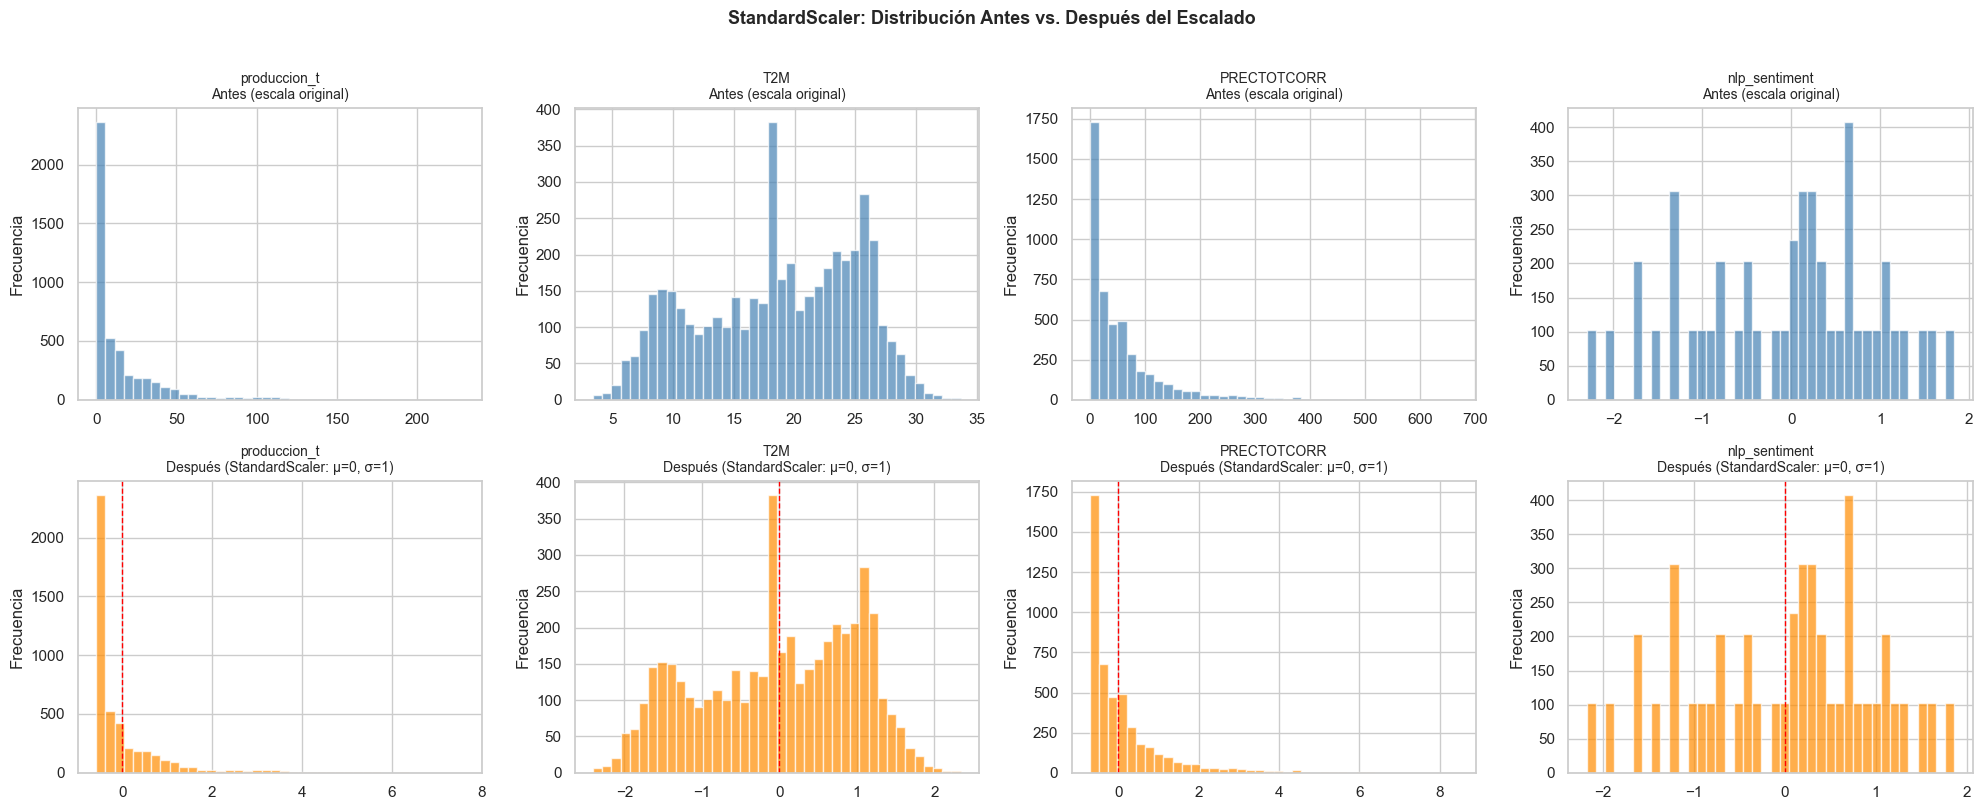

Gráfico guardado en data/processed/visualizacion_escalado.png


In [7]:
# Variables de interés para la visualización
VIZ_COLS = [c for c in ['produccion_t', 'T2M', 'PRECTOTCORR', 'nlp_sentiment']
            if c in df_scaled.columns]

if VIZ_COLS:
    fig, axes = plt.subplots(2, len(VIZ_COLS), figsize=(5 * len(VIZ_COLS), 8))
    if len(VIZ_COLS) == 1:
        axes = axes.reshape(2, 1)

    for i, col in enumerate(VIZ_COLS):
        # Antes del escalado
        axes[0, i].hist(df[col].dropna(), bins=40, color='steelblue', alpha=0.7)
        axes[0, i].set_title(f'{col}\nAntes (escala original)', fontsize=10)
        axes[0, i].set_ylabel('Frecuencia')

        # Después del escalado
        axes[1, i].hist(df_scaled[col].dropna(), bins=40, color='darkorange', alpha=0.7)
        axes[1, i].set_title(f'{col}\nDespués (StandardScaler: μ=0, σ=1)', fontsize=10)
        axes[1, i].set_ylabel('Frecuencia')
        axes[1, i].axvline(0, color='red', linestyle='--', linewidth=1, label='μ=0')

    plt.suptitle('StandardScaler: Distribución Antes vs. Después del Escalado',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('../../data/processed/visualizacion_escalado.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Gráfico guardado en data/processed/visualizacion_escalado.png")
else:
    print("No se encontraron columnas de ejemplo para visualizar.")


## 6. Verificación Final del Dataset

Comprobamos que el dataset resultante esté limpio, sin NaNs, y que las variables escaladas estén efectivamente entre 0 y 1.

In [8]:
# Verificación con StandardScaler: media ~ 0, std ~ 1 en columnas escaladas (sobre TRAIN)
stats_train = df_scaled.iloc[:int(len(df_scaled)*0.8)][cols_to_scale].agg(['mean','std'])
out_of_spec = stats_train.loc[:, (stats_train.loc['mean'].abs() > 0.1) |
                                   (stats_train.loc['std']  - 1).abs() > 0.1]

if out_of_spec.empty:
    print("✅ StandardScaler verificado: media~0 y std~1 en todas las columnas (sobre Train).")
else:
    print(f"⚠️  Columnas con desviación en train (revisar):\n{out_of_spec}")

# NaNs restantes
total_nans = df_scaled[cols_to_scale].isna().sum().sum()
print(f"\n{'✅' if total_nans == 0 else '⚠️ '} NaNs en columnas escaladas: {total_nans}")
print(f"Shape final del dataset: {df_scaled.shape[0]:,} filas × {df_scaled.shape[1]} columnas")
df_scaled[cols_to_scale[:6]].describe().round(3)


⚠️  Columnas con desviación en train (revisar):
      produccion_t  cosecha_ha  precio_chacra_kg  num_emergencias  \
mean  4.229421e-17         0.0     -2.306957e-17     4.613914e-17   
std   1.000135e+00         0.0      1.000135e+00     1.000135e+00   

      total_afectados  ALLSKY_SFC_SW_DWN   PRECTOTCORR          QV2M  \
mean    -7.689856e-18      -4.498566e-16  7.689856e-18 -1.422623e-16   
std      1.000135e+00       1.000135e+00  1.000135e+00  1.000135e+00   

              RH2M           T2M  ...     WS2M_lag6    WS2M_lag12  \
mean -6.767074e-16 -4.613914e-17  ...  1.614870e-16  5.382900e-17   
std   1.000135e+00  1.000135e+00  ...  1.000135e+00  1.000135e+00   

      ALLSKY_SFC_SW_DWN_lag1  ALLSKY_SFC_SW_DWN_lag3  ALLSKY_SFC_SW_DWN_lag6  \
mean           -9.843016e-16           -1.268826e-15            4.306320e-16   
std             1.000135e+00            1.000135e+00            1.000135e+00   

      ALLSKY_SFC_SW_DWN_lag12  nlp_sentiment_lag1  nlp_sentiment_lag3  \
mean 

,produccion_t,cosecha_ha,precio_chacra_kg,num_emergencias,total_afectados,ALLSKY_SFC_SW_DWN
count,4620.000,4620.0,4620.000,4620.000,4620.000,4620.000
mean,0.017,0.0,-0.014,-0.054,-0.017,-0.066
std,1.014,0.0,1.005,0.901,0.895,0.989
min,-0.583,0.0,-2.195,-0.269,-0.085,-2.934
25%,-0.583,0.0,-0.937,-0.269,-0.085,-0.769
50%,-0.404,0.0,-0.098,-0.269,-0.085,-0.158
75%,0.167,0.0,0.741,-0.269,-0.085,0.422
max,7.592,0.0,1.831,15.582,46.690,4.366


## 7. Exportar Dataset Final

Este es el **dataset maestro** que entrará directamente al modelo LSTM. Contiene:
- ✅ Sentimiento NLP (Act. 01)
- ✅ Codificación cíclica del tiempo (Act. 02)
- ✅ `cosecha_ha` preservada (dataset_integrado.csv — Fase 1)
- ✅ Rezagos temporales t-1, t-3, t-6, t-12 (Act. 03)
- ✅ Estandarización StandardScaler μ=0, σ=1 (Act. 04 — [52])

**La Fase 2: Feature Engineering para LSTM está completa.**

In [9]:
df_scaled.to_csv(OUTPUT_FILE, index=False)
print(f"✅ Dataset final exportado a: {OUTPUT_FILE}")
print(f"   {df_scaled.shape[0]:,} filas × {df_scaled.shape[1]} columnas")
print(f"\nResumen de la Fase 2 completada:")
print(f"  📄 master_dataset_fase2_final.csv → dataset listo para LSTM")
print(f"  🔧 scalers/standard_scaler_fase2.joblib → StandardScaler para inferencia")
print(f"  🔧 scalers/cols_to_scale.joblib          → columnas del scaler")


✅ Dataset final exportado a: ../../data/processed/master_dataset_fase2_final.csv
   4,620 filas × 56 columnas

Resumen de la Fase 2 completada:
  📄 master_dataset_fase2_final.csv → dataset listo para LSTM
  🔧 scalers/standard_scaler_fase2.joblib → StandardScaler para inferencia
  🔧 scalers/cols_to_scale.joblib          → columnas del scaler
